import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ── 1. Datos ──────────────────────────────────────────────────────────────────
df = pd.read_excel('KmPro,KmRea,KmVac.xlsx')
df['Fecha'] = pd.to_datetime(dict(year=df['Año'], month=df['Mes'], day=1))
ts_full = df.groupby('Fecha')['Km Realizados'].sum().asfreq('MS')

# Feb 2026 está incompleto → lo excluimos
ts = ts_full[ts_full.index < '2026-02-01']

train = ts['2021':'2024']
test  = ts['2025']
print(f"Train: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} meses)")
print(f"Test : {test.index[0].date()} → {test.index[-1].date()}  ({len(test)} meses)")

# ── 2. Selección de modelo ────────────────────────────────────────────────────
configs = [
    ('SARIMA(0,1,1)(0,1,1)[12]', (0,1,1),(0,1,1,12)),
    ('SARIMA(1,1,1)(1,0,1)[12]', (1,1,1),(1,0,1,12)),
    ('SARIMA(0,1,1)(1,0,1)[12]', (0,1,1),(1,0,1,12)),
    ('SARIMA(1,1,0)(0,1,1)[12]', (1,1,0),(0,1,1,12)),
]
print("\nComparación de modelos:")
best_mape, best_cfg, best_name = 999, None, ''
for name, order, sorder in configs:
    try:
        m = SARIMAX(train, order=order, seasonal_order=sorder,
                    enforce_stationarity=False, enforce_invertibility=False)
        r = m.fit(disp=False, maxiter=300)
        fc = r.get_forecast(steps=len(test)).predicted_mean
        fc.index = test.index
        ratio = fc.mean() / test.mean()
        if not (0.5 < ratio < 2): raise ValueError('diverge')
        mape = np.mean(np.abs((test - fc)/test))*100
        mae  = mean_absolute_error(test, fc)
        print(f"  ✅ {name}: AIC={r.aic:.0f}  MAPE={mape:.1f}%  MAE={mae:,.0f}")
        if mape < best_mape:
            best_mape, best_cfg, best_name = mape, (order, sorder), name
    except Exception as e:
        print(f"  ❌ {name}: {e}")

print(f"\n→ Mejor modelo: {best_name}")
order, sorder = best_cfg

# ── 3. Ajuste final ───────────────────────────────────────────────────────────
model  = SARIMAX(train, order=order, seasonal_order=sorder,
                 enforce_stationarity=False, enforce_invertibility=False)
result = model.fit(disp=False, maxiter=300)
print(result.summary())

fc_obj  = result.get_forecast(steps=len(test))
fc_mean = fc_obj.predicted_mean
fc_ci   = fc_obj.conf_int(alpha=0.05)
fc_mean.index = test.index
fc_ci.index   = test.index

mae  = mean_absolute_error(test, fc_mean)
rmse = np.sqrt(mean_squared_error(test, fc_mean))
mape = np.mean(np.abs((test - fc_mean)/test))*100
print(f"\nMAE : {mae:,.0f} km  |  RMSE: {rmse:,.0f} km  |  MAPE: {mape:.1f}%")

fitted = result.fittedvalues

# Componente estacional
decomp  = seasonal_decompose(train, model='additive', period=12)
MESES   = ['Ene','Feb','Mar','Abr','May','Jun',
           'Jul','Ago','Sep','Oct','Nov','Dic']
sea_mes = (pd.Series(decomp.seasonal.values, index=decomp.seasonal.index)
           .groupby(lambda x: x.month).mean())
sea_mes.index = MESES

# Pronóstico 2026 (reentrenar con todo 2021–2025)
model2  = SARIMAX(ts, order=order, seasonal_order=sorder,
                  enforce_stationarity=False, enforce_invertibility=False)
res2    = model2.fit(disp=False, maxiter=300)
fc2_obj = res2.get_forecast(steps=12)
fc2     = fc2_obj.predicted_mean
fc2_ci  = fc2_obj.conf_int(alpha=0.05)
fc2_ci80 = res2.get_forecast(steps=12).conf_int(alpha=0.20)
fc2.index     = pd.date_range('2026-01-01', periods=12, freq='MS')
fc2_ci.index  = fc2.index
fc2_ci80.index = fc2.index

# ── 4. Paleta ─────────────────────────────────────────────────────────────────
BLUE  = '#1C4E80'
ORAN  = '#E8872A'
GREEN = '#21A659'
RED   = '#E74C3C'
GRAY  = '#B0B8C1'
BG    = '#F4F7FB'
CARD  = '#FFFFFF'
fmt_K = mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k')

fig = plt.figure(figsize=(20, 22), facecolor=BG)
fig.suptitle(f'{best_name} — Km Realizados\nEstacionalidad Anual (s=12)',
             fontsize=19, fontweight='bold', color=BLUE, y=0.987)
gs = fig.add_gridspec(4, 2, hspace=0.52, wspace=0.30,
                      left=0.08, right=0.96, top=0.96, bottom=0.04)

# ── A: Serie histórica + ajuste ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(CARD)
ax1.plot(train.index, train.values/1000, color=GRAY, lw=1.5,
         alpha=0.9, label='Real (train 2021–2024)')
ax1.plot(fitted.index, fitted.values/1000, color=BLUE, lw=1.3,
         alpha=0.75, label='Ajuste in-sample')
ax1.set_title('Serie histórica Km Realizados con ajuste del modelo',
              fontsize=12, fontweight='bold', color=BLUE, pad=8)
ax1.set_ylabel('Km (miles)', fontsize=10)
ax1.yaxis.set_major_formatter(fmt_K)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax1.tick_params(axis='x', labelsize=8)
ax1.legend(fontsize=9, loc='upper left', framealpha=0.7)
ax1.grid(axis='y', linestyle='--', alpha=0.35)
ax1.spines[['top','right']].set_visible(False)
for yr in ['2022-01-01','2023-01-01','2024-01-01']:
    ax1.axvline(pd.Timestamp(yr), color=BLUE, lw=0.6, linestyle=':', alpha=0.3)

# ── B: Pronóstico 2025 vs Real ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
ax2.set_facecolor(CARD)
ctx = train[-6:]
ax2.plot(ctx.index, ctx.values/1000, color=GRAY, lw=1.3,
         alpha=0.5, label='Real (jul–dic 2024)')
ax2.fill_between(fc_ci.index,
                 fc_ci.iloc[:,0]/1000, fc_ci.iloc[:,1]/1000,
                 color=ORAN, alpha=0.18, label='IC 95%')
ax2.plot(fc_mean.index, fc_mean.values/1000,
         color=ORAN, lw=2.3, linestyle='--', label='Pronóstico SARIMA')
ax2.plot(test.index, test.values/1000,
         color=BLUE, lw=2.0, marker='o', markersize=6, label='Real 2025')
ax2.set_title('Pronóstico SARIMA vs Real 2025 (validación)',
              fontsize=12, fontweight='bold', color=BLUE, pad=8)
ax2.set_ylabel('Km (miles)', fontsize=10)
ax2.yaxis.set_major_formatter(fmt_K)
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax2.tick_params(axis='x', labelsize=8)
ax2.legend(fontsize=9, framealpha=0.8, loc='lower right')
ax2.grid(axis='y', linestyle='--', alpha=0.35)
ax2.spines[['top','right']].set_visible(False)
txt = f"MAE = {mae/1000:.1f}k km   RMSE = {rmse/1000:.1f}k km   MAPE = {mape:.1f}%"
ax2.text(0.01, 0.97, txt, transform=ax2.transAxes, ha='left',
         fontsize=9.5, va='top',
         bbox=dict(boxstyle='round,pad=0.35', fc='#FFF8EC', ec=ORAN, lw=1.2))

# ── C: Componente estacional por mes ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
ax3.set_facecolor(CARD)
bar_colors = [RED   if v == sea_mes.min() else
              GREEN if v == sea_mes.max() else
              BLUE  for v in sea_mes.values]
bars = ax3.bar(sea_mes.index, sea_mes.values/1000,
               color=bar_colors, edgecolor='white',
               linewidth=0.6, width=0.65, zorder=3)
ax3.axhline(0, color=GRAY, lw=1, linestyle='--')
ax3.set_title('Componente estacional promedio\npor mes del año',
              fontsize=11, fontweight='bold', color=BLUE, pad=8)
ax3.set_ylabel('Desviación vs tendencia (k km)', fontsize=10)
ax3.yaxis.set_major_formatter(fmt_K)
ax3.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax3.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, sea_mes.values):
    offset = 0.5 if val >= 0 else -1.5
    ax3.text(bar.get_x()+bar.get_width()/2, val/1000+offset,
             f'{val/1000:.1f}k', ha='center', va='bottom',
             fontsize=7.5, fontweight='bold', color='#222')
mejor_mes = sea_mes.idxmax()
peor_mes  = sea_mes.idxmin()
ax3.text(0.5, -0.18, f'📈 Mes mayor: {mejor_mes}   📉 Mes menor: {peor_mes}',
         transform=ax3.transAxes, ha='center',
         fontsize=10, fontweight='bold', color=BLUE)

# ── D: Residuales 2025 ───────────────────────────────────────────────────────
resid = test - fc_mean
ax4   = fig.add_subplot(gs[2, 1])
ax4.set_facecolor(CARD)
rc = [GREEN if r >= 0 else RED for r in resid.values]
ax4.bar(range(len(resid)), resid.values/1000, color=rc,
        edgecolor='white', linewidth=0.4, width=0.65, zorder=3)
ax4.axhline(0, color=GRAY, lw=1, linestyle='--')
ax4.set_xticks(range(len(resid)))
ax4.set_xticklabels(MESES, fontsize=9)
ax4.set_title('Error del pronóstico\n(Real − Pronóstico) 2025',
              fontsize=11, fontweight='bold', color=BLUE, pad=8)
ax4.set_ylabel('Error (k km)', fontsize=10)
ax4.yaxis.set_major_formatter(fmt_K)
ax4.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)
ax4.spines[['top','right']].set_visible(False)
ax4.legend(handles=[Patch(color=GREEN, label='Real > Pronóstico'),
                    Patch(color=RED,   label='Real < Pronóstico')],
           fontsize=8, framealpha=0.7)

# ── E: Pronóstico 2026 ────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[3, :])
ax5.set_facecolor(CARD)

ctx2 = ts[-12:]
ax5.plot(ctx2.index, ctx2.values/1000, color=GRAY, lw=2.0,
         alpha=0.8, marker='o', markersize=4, label='Real 2025')

ax5.plot([ctx2.index[-1], fc2.index[0]],
         [ctx2.values[-1]/1000, fc2.values[0]/1000],
         color=GREEN, lw=2.0, linestyle='--', alpha=0.5)

ax5.fill_between(fc2_ci80.index,
                 fc2_ci80.iloc[:,0]/1000, fc2_ci80.iloc[:,1]/1000,
                 color=GREEN, alpha=0.25, label='IC 80%')

ax5.plot(fc2.index, fc2.values/1000,
         color=GREEN, lw=2.3, linestyle='--',
         marker='o', markersize=6, label='Pronóstico 2026')

real_ene26 = ts_full['2026-01-01']
ax5.plot([pd.Timestamp('2026-01-01')], [real_ene26/1000],
         color=BLUE, marker='D', markersize=8, zorder=6,
         label=f'Real ene 2026 ({real_ene26/1000:.0f}k)')

ax5.axvline(pd.Timestamp('2026-01-01'), color=GRAY, lw=1, linestyle=':', alpha=0.5)

all_vals = np.concatenate([ctx2.values/1000, fc2.values/1000,
                           fc2_ci80.values.flatten()/1000])
ax5.set_ylim(all_vals.min() * 0.96, all_vals.max() * 1.06)

ax5.set_title('Pronóstico Km Realizados 2026 (modelo entrenado 2021–2025)',
              fontsize=12, fontweight='bold', color=BLUE, pad=8)
ax5.set_ylabel('Km (miles)', fontsize=10)
ax5.yaxis.set_major_formatter(fmt_K)
ax5.xaxis.set_major_locator(mdates.MonthLocator())
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax5.tick_params(axis='x', labelsize=8)
ax5.legend(fontsize=9, framealpha=0.8, loc='lower right')
ax5.grid(axis='y', linestyle='--', alpha=0.35)
ax5.spines[['top','right']].set_visible(False)
for date, val in fc2.items():
    ax5.text(date, val/1000 + (all_vals.max()-all_vals.min())*0.02,
             f'{val/1000:.0f}k', ha='center', va='bottom',
             fontsize=7.5, color=GREEN, fontweight='bold')

plt.savefig('sarima_km_realizados.png', dpi=150, bbox_inches='tight', facecolor=BG)
print("\n✅  Guardado: sarima_km_realizados.png")

print("\n── Pronóstico Km Realizados 2026 ──")
for d, v in fc2.items():
    print(f"  {d.strftime('%b %Y')}: {v:>12,.0f} km")
print(f"\n  Total anual estimado 2026: {fc2.sum():,.0f} km")

⚠ Último mes incompleto eliminado. Períodos usados: 55


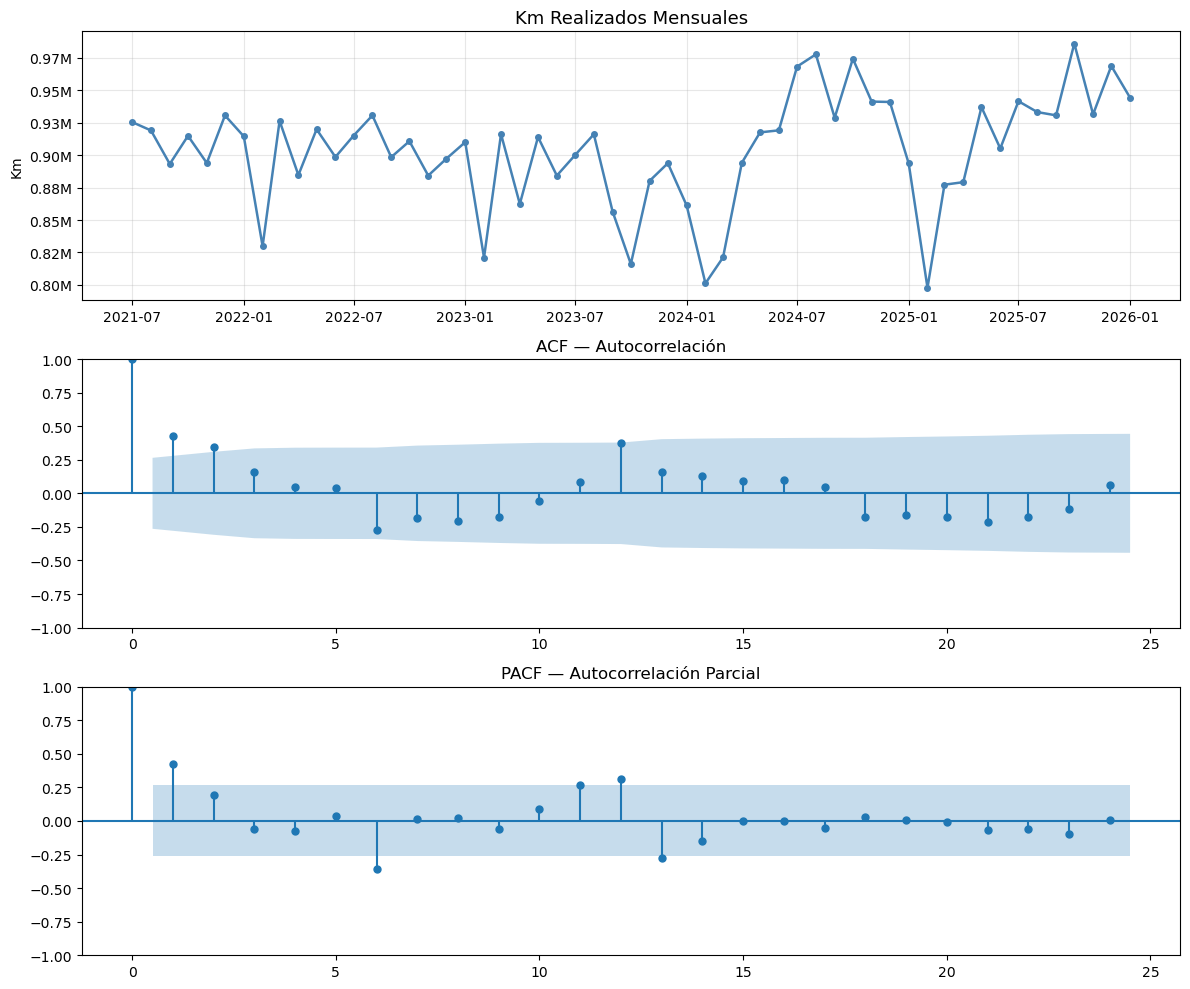


=== Resumen del Modelo ===
                                     SARIMAX Results                                      
Dep. Variable:                      Km Realizados   No. Observations:                   55
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -476.207
Date:                            Sat, 21 Mar 2026   AIC                            964.414
Time:                                    07:46:44   BIC                            974.547
Sample:                                07-01-2021   HQIC                           968.078
                                     - 01-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1392.8378   7508.859      0.185      0.853   -1.33e+04    1.61e+04
ar.L1  

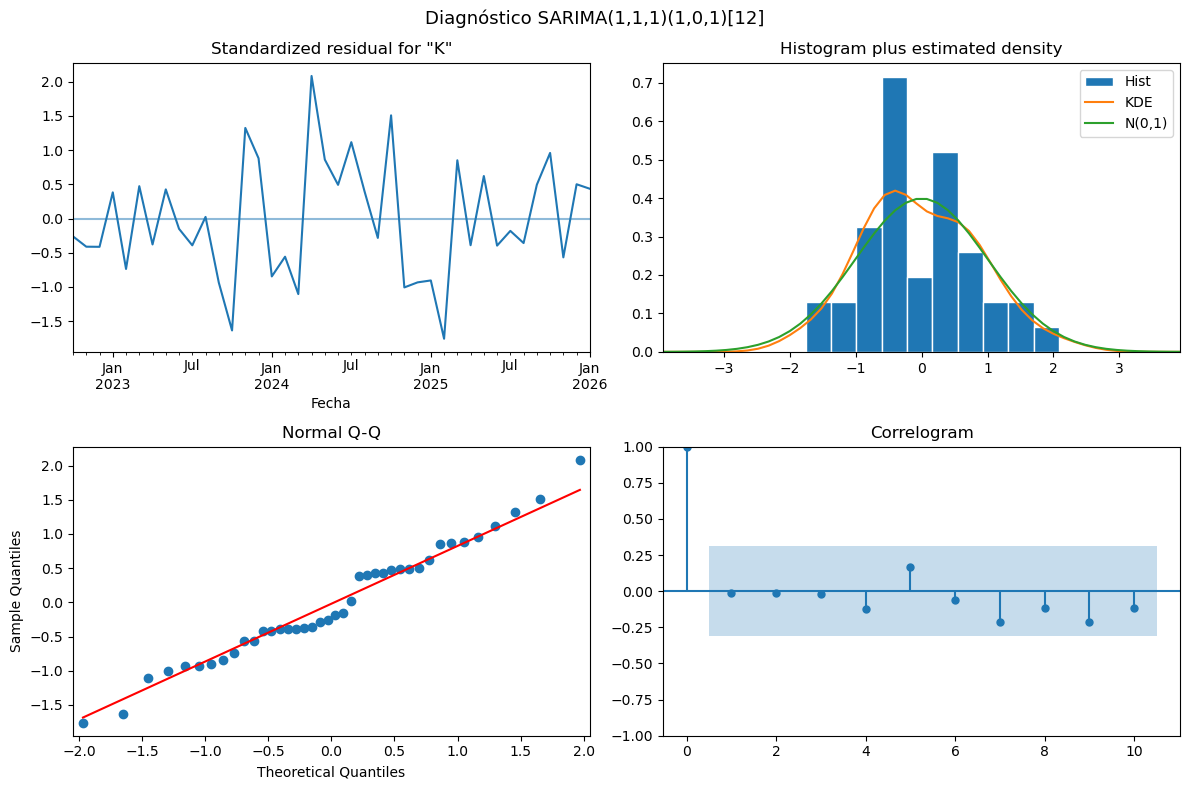

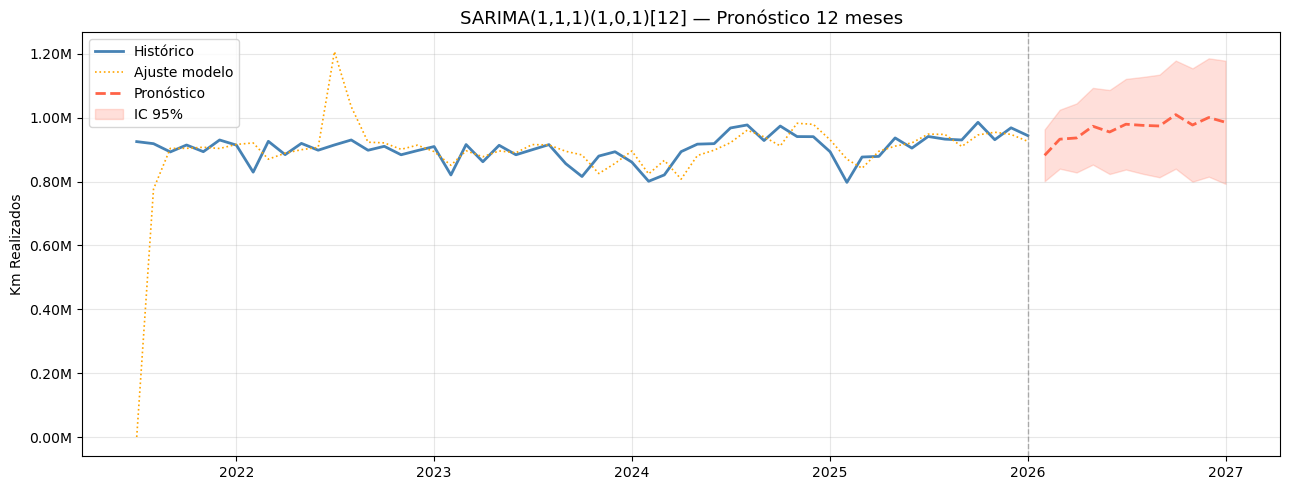

Gráfico guardado: pronostico_sarima.png

=== Pronóstico 12 meses ===
  Fecha  Km Pronosticados  IC Inferior (95%)  IC Superior (95%)
2026-02          882524.0           801508.0           963539.0
2026-03          933058.0           840712.0          1025404.0
2026-04          936981.0           828863.0          1045099.0
2026-05          973607.0           853476.0          1093738.0
2026-06          955589.0           824034.0          1087143.0
2026-07          979946.0           838038.0          1121854.0
2026-08          976337.0           824734.0          1127940.0
2026-09          974435.0           813735.0          1135135.0
2026-10         1009959.0           840646.0          1179272.0
2026-11          977501.0           799994.0          1155009.0
2026-12         1000966.0           815625.0          1186306.0
2027-01          985985.0           793129.0          1178840.0


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────
# 1. CARGA Y PREPARACIÓN
# ─────────────────────────────────────────
df = pd.read_excel("KmPro,KmRea,KmVac.xlsx")

monthly = (
    df.groupby(["Año", "Mes"])["Km Realizados"]
    .sum()
    .reset_index()
    .sort_values(["Año", "Mes"])
)

monthly["Fecha"] = pd.to_datetime(
    monthly["Año"].astype(str) + "-" + monthly["Mes"].astype(str) + "-01"
)

ts = monthly.set_index("Fecha")["Km Realizados"]
ts.index.freq = "MS"

# Eliminar el último mes si es incompleto (menos del 80% del promedio)
promedio = ts[:-1].mean()
if ts.iloc[-1] < promedio * 0.80:
    ts = ts.iloc[:-1]
    print(f"⚠ Último mes incompleto eliminado. Períodos usados: {len(ts)}")
else:
    print(f"Períodos usados: {len(ts)}")

# ─────────────────────────────────────────
# 2. VISUALIZACIÓN + ACF/PACF
# ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(ts, marker="o", markersize=4, linewidth=1.8, color="steelblue")
axes[0].set_title("Km Realizados Mensuales", fontsize=13)
axes[0].set_ylabel("Km")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M"))
axes[0].grid(True, alpha=0.3)

plot_acf(ts, lags=24, ax=axes[1], title="ACF — Autocorrelación")
plot_pacf(ts, lags=24, ax=axes[2], title="PACF — Autocorrelación Parcial")

plt.tight_layout()
plt.savefig("serie_acf_pacf.png", dpi=150)
plt.show()

# ─────────────────────────────────────────
# 3. MODELO SARIMA — parámetros estables
#    (1,1,1)(1,0,1)[12]
#    D=0 evita doble diferenciación que
#    provoca inestabilidad numérica
# ─────────────────────────────────────────
order          = (1, 1, 1)
seasonal_order = (1, 0, 1, 12)

modelo = SARIMAX(
    ts,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
    trend="c",
)

resultado = modelo.fit(disp=False, maxiter=200)
print("\n=== Resumen del Modelo ===")
print(resultado.summary())
print(f"\nAIC: {resultado.aic:.2f}  |  BIC: {resultado.bic:.2f}")

# ─────────────────────────────────────────
# 4. DIAGNÓSTICO
# ─────────────────────────────────────────
resultado.plot_diagnostics(figsize=(12, 8))
plt.suptitle("Diagnóstico SARIMA(1,1,1)(1,0,1)[12]", fontsize=13)
plt.tight_layout()
plt.savefig("diagnostico_sarima.png", dpi=150)
plt.show()

# ─────────────────────────────────────────
# 5. PRONÓSTICO 12 MESES
# ─────────────────────────────────────────
n_forecast = 12
forecast  = resultado.get_forecast(steps=n_forecast)
pred_mean = forecast.predicted_mean
pred_ci   = forecast.conf_int(alpha=0.05)

# Valores ajustados dentro del histórico
fitted = resultado.fittedvalues

# ─────────────────────────────────────────
# 6. GRÁFICO FINAL
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(ts,        label="Histórico",     color="steelblue", linewidth=2)
ax.plot(fitted,    label="Ajuste modelo", color="orange",    linewidth=1.2, linestyle=":")
ax.plot(pred_mean, label="Pronóstico",    color="tomato",    linewidth=2,   linestyle="--")
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color="tomato", alpha=0.2, label="IC 95%",
)

# Línea vertical que separa histórico / pronóstico
ax.axvline(ts.index[-1], color="gray", linestyle="--", linewidth=1, alpha=0.6)

ax.set_title("SARIMA(1,1,1)(1,0,1)[12] — Pronóstico 12 meses", fontsize=13)
ax.set_ylabel("Km Realizados")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pronostico_sarima.png", dpi=150)
plt.show()
print("Gráfico guardado: pronostico_sarima.png")

# ─────────────────────────────────────────
# 7. TABLA DE PRONÓSTICO
# ─────────────────────────────────────────
tabla = pd.DataFrame({
    "Fecha":              pred_mean.index.strftime("%Y-%m"),
    "Km Pronosticados":   pred_mean.values.round(0),
    "IC Inferior (95%)":  pred_ci.iloc[:, 0].values.round(0),
    "IC Superior (95%)":  pred_ci.iloc[:, 1].values.round(0),
})
print("\n=== Pronóstico 12 meses ===")
print(tabla.to_string(index=False))